<a href="https://colab.research.google.com/github/keswong/phd_listing_repo/blob/main/3_10_1_Classification_Model_for_Automated_Diagnosis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CPS diagnosis of problem-solving, scripting and off-task dimensions for CPS Segment presented to teachers**

<ipython-input-56-328de86acdaf>:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(f)


Classification Report:
               precision    recall  f1-score   support

         SS1      1.000     0.005     0.009       215
         SS2      0.653     0.739     0.693      1182
         SS3      0.406     0.438     0.421       349
         SS4      0.471     0.296     0.364        27
         SS5      0.643     0.191     0.295        94
         SS6      0.000     0.000     0.000       126
         SS7      0.000     0.000     0.000        22
         SS8      0.000     0.000     0.000        51
         SC1      0.774     0.749     0.761      1580
         SC2      0.733     0.641     0.684       859
       OTHER      0.783     0.919     0.846      2654

   micro avg      0.730     0.730     0.730      7159
   macro avg      0.497     0.362     0.370      7159
weighted avg      0.717     0.730     0.704      7159
 samples avg      0.730     0.730     0.730      7159

Accuracy: 0.730
Precision: 0.717
Recall: 0.730
F1 Score: 0.704



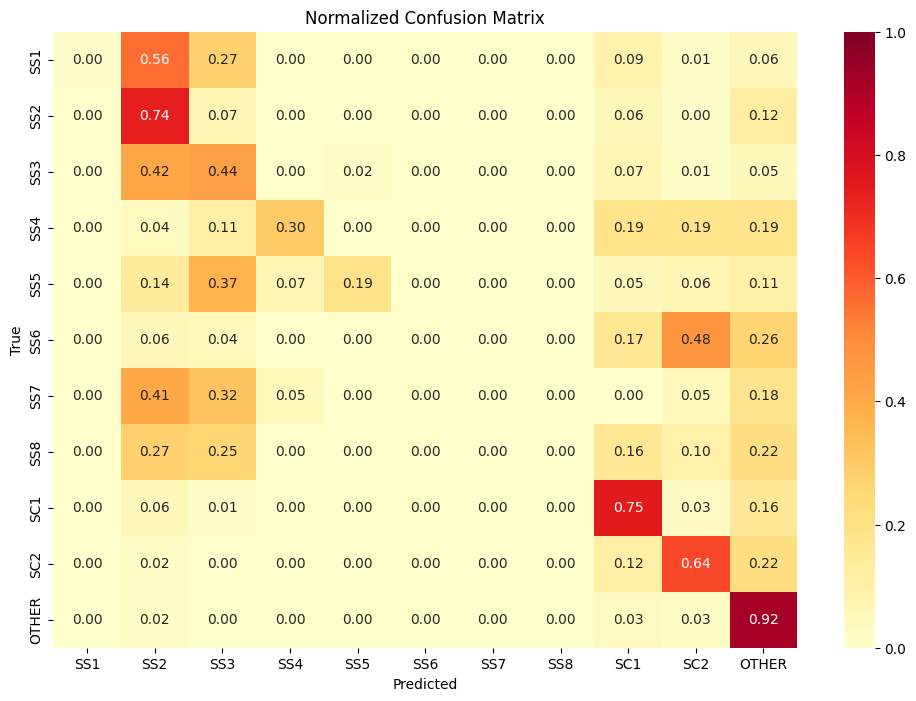

In [ ]:
with open('.../df_TFIDF_Audio_features_all.pkl', 'rb') as f:
    df = pickle.load(f)
df = df[df['Dimension'] == 'cognitive']
df = df.drop_duplicates(subset=["Utterance Number", "Categories"])
# Ensure the utterance is string format
df['Utterance'] = df['Utterance'].astype(str)

# Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

batch_size = 32

test_input_ids = []
test_attention_masks = []
for utterance in df['Utterance']:
    encoded_dict = tokenizer.encode_plus(
                        utterance,                      # Sentence to encode.
                        add_special_tokens = True, # Add '[CLS]' and '[SEP]'
                        padding= 'max_length',
                        return_attention_mask = True,   # Construct attn. masks.
                        return_tensors = 'pt',     # Return pytorch tensors.
                   )
    test_input_ids.append(encoded_dict['input_ids'])
    test_attention_masks.append(encoded_dict['attention_mask'])
test_input_ids = torch.cat(test_input_ids, dim=0)
test_attention_masks = torch.cat(test_attention_masks, dim=0)

test_dataset = TensorDataset(test_input_ids, test_attention_masks)
test_dataloader = DataLoader(
            test_dataset, # The validation samples.
            sampler = SequentialSampler(test_dataset), # Pull out batches sequentially.
            batch_size = batch_size # Evaluate with this batch size.
        )

predictions = []
for batch in test_dataloader:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        with torch.no_grad():
            output= model(b_input_ids,
                                   token_type_ids=None,
                                   attention_mask=b_input_mask)
            logits = output.logits
            logits = logits.detach().cpu().numpy()
            pred_flat = np.argmax(logits, axis=1).flatten()

            predictions.extend(list(pred_flat))

df['target'] = predictions


label_dict = {'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5 , 'SS7': 6, 'SS8': 7,  'SC1': 8, 'SC2': 9, 'OTHER': 10}

true_vals = df["label"].values  # True labels from df
predictions = df["target"].values  # Predicted labels from df
inverse_label_dict = {v: k for k, v in label_dict.items()}
predictions = df["target"].values
predicted_labels = [inverse_label_dict[pred] for pred in predictions]
df["predicted_label"] = predicted_labels

y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True,
            xticklabels=label_dict.keys(), yticklabels=label_dict.keys(),
            vmin=0, vmax=1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

df.to_excel('.../automated_diagnosis_for_teachers.xlsx', index=False)

Classification Report:
               precision    recall  f1-score   support

         AS1      0.945     0.912     0.928       569
         AS2      0.930     0.970     0.949       920
         AS3      0.950     0.487     0.644        39

   micro avg      0.936     0.936     0.936      1528
   macro avg      0.942     0.790     0.841      1528
weighted avg      0.936     0.936     0.934      1528
 samples avg      0.936     0.936     0.936      1528

Accuracy: 0.936
Precision: 0.936
Recall: 0.936
F1 Score: 0.934



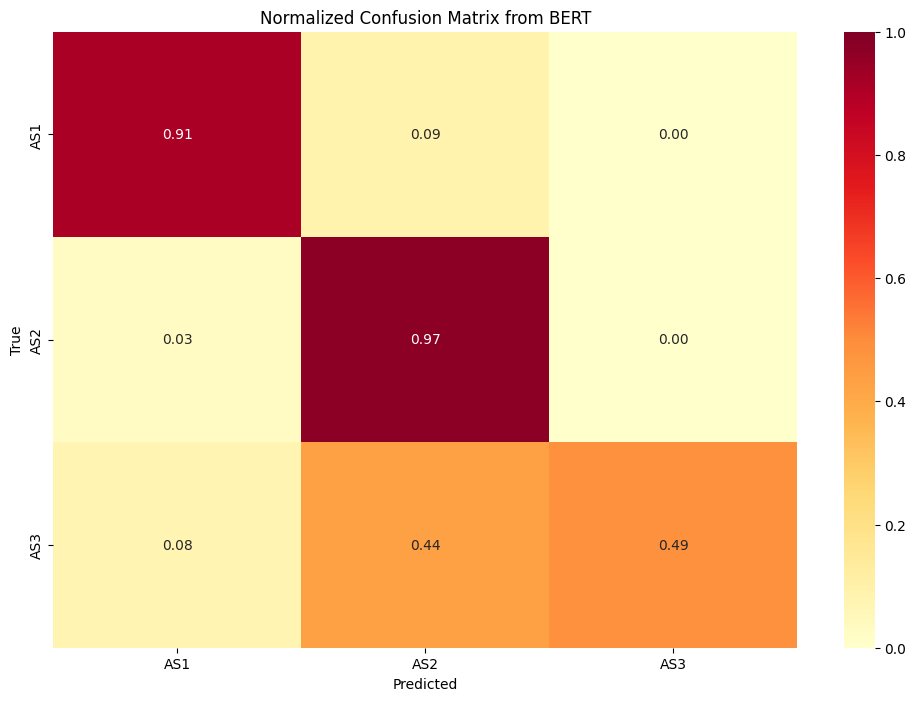

In [ ]:
df = pd.read_pickle('.../AFFECTIVE_df.pkl')
df['Utterance'] = df['Utterance'].astype(str)

# Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

batch_size = 32

test_input_ids = []
test_attention_masks = []
for utterance in df['Utterance']:
    encoded_dict = tokenizer.encode_plus(
                        utterance,                      # Sentence to encode.
                        add_special_tokens = True, # Add '[CLS]' and '[SEP]'
                        padding= 'max_length',
                        return_attention_mask = True,   # Construct attn. masks.
                        return_tensors = 'pt',     # Return pytorch tensors.
                   )
    test_input_ids.append(encoded_dict['input_ids'])
    test_attention_masks.append(encoded_dict['attention_mask'])
test_input_ids = torch.cat(test_input_ids, dim=0)
test_attention_masks = torch.cat(test_attention_masks, dim=0)

test_dataset = TensorDataset(test_input_ids, test_attention_masks)
test_dataloader = DataLoader(
            test_dataset, # The validation samples.
            sampler = SequentialSampler(test_dataset), # Pull out batches sequentially.
            batch_size = batch_size # Evaluate with this batch size.
        )

predictions = []
for batch in test_dataloader:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        with torch.no_grad():
            output= model(b_input_ids,
                                   token_type_ids=None,
                                   attention_mask=b_input_mask)
            logits = output.logits
            logits = logits.detach().cpu().numpy()
            pred_flat = np.argmax(logits, axis=1).flatten()

            predictions.extend(list(pred_flat))

df['target'] = predictions
label_dict = {'AS1': 0, 'AS2': 1, 'AS3': 2}

true_vals = df["label"].values
predictions = df["target"].values

# Binarize the true labels for multi-class classification
y_true_binarized = label_binarize(true_vals, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(predictions, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3, zero_division=0)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')
print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')

cm = confusion_matrix(true_vals, predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrRd', cbar=True,
            xticklabels=label_dict.keys(), yticklabels=label_dict.keys(),
            vmin=0, vmax=1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix from BERT')
plt.show()

df.to_excel('.../automated_diagnosis_for_teachers_affective.xlsx', index=False)
